# Week 6 - Bivariate Analysis, part 2

# 1. Lesson: no lesson this week

# 2. Weekly graph question

Suppose you wanted to show the nitrate and phosphate level in a water sample.  What are the advantages and disadvantages of showing this as an area plot, as opposed to two separate line graphs?  How would you adjust the graphs shown to improve the presentation?

In [1]:
import numpy as np
import seaborn as sns
import pandas as pd

Text(0, 0.5, 'Nitrate level (% of eutrophic value)')

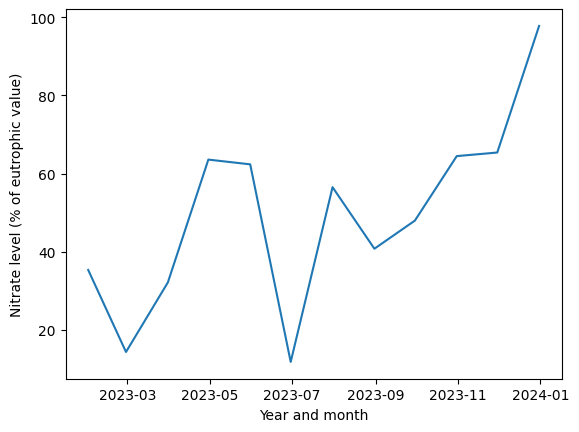

In [2]:
numdates = 12
np.random.seed(0)
time_series = 100 * (np.random.normal(size = numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='ME')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")

Text(0, 0.5, 'Phosphate level (% of eutrophic value)')

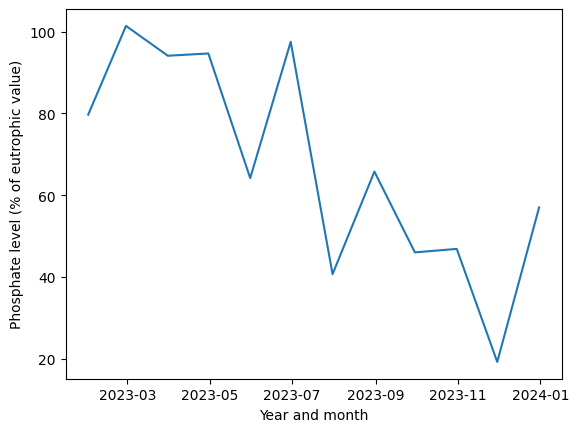

In [3]:
np.random.seed(1)
time_series_2 =  100 * (1 - (np.random.normal(size = numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='ME')
ax = sns.lineplot(x = datearray, y = time_series_2)
ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")

<Axes: >

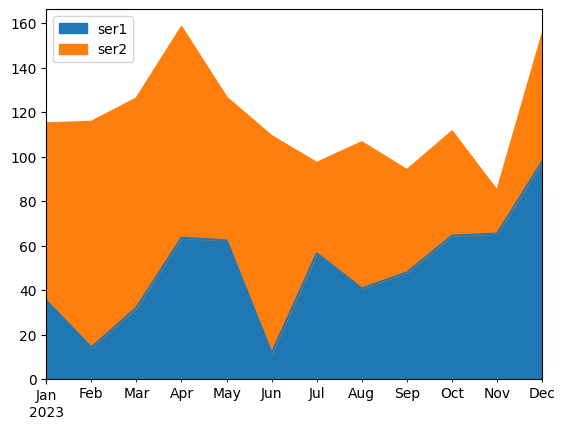

In [4]:
df = pd.DataFrame({'ser1': time_series, 'ser2': time_series_2}, index = datearray)
df.plot.area()

### Section 2 – Answer (Weekly graph question)

**Area plot (stacked) – advantages**
- Shows the *total nutrient load* (nitrate + phosphate) at each time point at a glance, and how the composition shifts over time.
- Works well if the two variables are parts of a whole and you care about the overall magnitude plus contributions.

**Area plot (stacked) – disadvantages**
- The upper series is easy to read, but the lower/stacked series can be harder to compare across time because its baseline is not constant (it sits on top of the other series).
- Can imply “additivity” and “parts-of-whole” even when nitrate and phosphate are independent measurements; that can be misleading.
- If one series is much larger, it can visually dominate and hide variation in the smaller one.

**Two separate line graphs – advantages**
- Each variable has its own stable baseline and y-axis, so trends, changes, and peaks are easier to read accurately.
- Avoids implying that the values should be summed.

**Two separate line graphs – disadvantages**
- Harder to compare the two series directly at the same time point (you’re visually switching between panels).
- Does not communicate a “total” if that is of interest.

**How I would adjust the graphs shown to improve the presentation**
- Put nitrate and phosphate on the *same* plot with a legend (two lines) so the time alignment is immediate; keep a single y-axis if they are comparable units/scale.
- If the goal is direct comparison rather than total, prefer a **two-line plot** or an **unstacked area plot** (filled under each line with transparency) instead of stacked area.
- Improve readability: rotate/format date ticks (e.g., monthly labels), add a title, and use consistent y-axis label wording/units for both nutrients.
- Use consistent axis limits across the separate plots (if kept separate) so differences aren’t driven by scaling.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Find correlations between pairs of variables.

- Draw scatterplots, especially when the correlation is large.

- Draw pairplots.

- Draw line graphs and/or area graphs when there is date or time data together with numerical data.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If the data are not useable, find some new data!

- Do you see any outliers?  (Data points that are far from the rest of the data).

- Are any data items highly correlated with each other, suggesting that they are redundant?

- For the line plots, do you see a trend or pattern over time?  Does this suggest that the data are changing over time (drifting) in such a way as to invalidate comparisons?

- Can you think of any confounding variables?  (Third variables that could explain any correlations between other variables.  These third variables may or may not be reported in the dataset.)

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import kagglehub

/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Instacart Market Basket Analysis Dataset

The Instacart Market Basket Analysis dataset contains transaction level records describing how customers build their grocery baskets over time. Each row in the order product data represents a single product that was added to a specific order. Order level information from the orders table was combined with product metadata to support behavioral analysis.

The main variables used in this notebook are summarized below.

- **order_id** – Unique identifier for each order placed on Instacart.
- **user_id** – Unique identifier for each customer.
- **product_id** – Unique identifier for each product purchased.
- **product_name** – Name of the product associated with the product ID.

- **add_to_cart_order** – The sequence position in which the product was added to the cart within an order.
- **reordered** – Binary indicator showing whether the product had been purchased previously by the same user.

- **order_number** – The number representing a customer's order history (first order, second order, etc.).
- **order_dow** – The day of the week the order was placed.
- **order_hour_of_day** – The hour of the day the order was placed.
- **days_since_prior_order** – Number of days since the customer’s previous order.

The analysis also includes several derived features:

- **basket_size** – Total number of items in an order.
- **reorder_rate** – Proportion of items in an order that were previously purchased by the same customer.
- **avg_add_to_cart_order** – The average cart position of items in an order, which reflects how items are added during the shopping process.

In [7]:
# Download dataset
path2 = kagglehub.dataset_download("psparks/instacart-market-basket-analysis")

print("Path to dataset files:", path2)

instacart_dir = Path(path2)
print("Instacart dataset folder:", instacart_dir)

100%|██████████| 197M/197M [00:01<00:00, 124MB/s]  

Extracting files...


Path to dataset files: /home/codespace/.cache/kagglehub/datasets/psparks/instacart-market-basket-analysis/versions/1
Instacart dataset folder: /home/codespace/.cache/kagglehub/datasets/psparks/instacart-market-basket-analysis/versions/1


In [8]:
# Load manageable files fully
orders = pd.read_csv(
    instacart_dir / "orders.csv",
    usecols=["order_id", "user_id", "order_number", "order_dow", "order_hour_of_day", "days_since_prior_order"]
)

products = pd.read_csv(instacart_dir / "products.csv")

print("orders shape:", orders.shape)
print("products shape:", products.shape)

display(orders.head())
display(products.head())

orders shape: (3421083, 6)
products shape: (49688, 4)


,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,1,2,8,NaN
1,2398795,1,2,3,7,15.0
2,473747,1,3,3,12,21.0
3,2254736,1,4,4,7,29.0
4,431534,1,5,4,15,28.0


,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


In [9]:
# Sample a manageable subset of orders
sample_orders = orders.sample(n=10000, random_state=42)
sample_order_ids = set(sample_orders["order_id"].astype(int))

print("Number of sampled order IDs:", len(sample_order_ids))

Number of sampled order IDs: 10000


In [10]:
# Load only matching rows from the large file using chunks
usecols = ["order_id", "product_id", "add_to_cart_order", "reordered"]

chunks = []
for chunk in pd.read_csv(
    instacart_dir / "order_products__prior.csv",
    usecols=usecols,
    dtype={
        "order_id": "int32",
        "product_id": "int32",
        "add_to_cart_order": "int16",
        "reordered": "int8",
    },
    chunksize=200_000
):
    filtered = chunk[chunk["order_id"].isin(sample_order_ids)]
    if not filtered.empty:
        chunks.append(filtered)

sample_order_products = pd.concat(chunks, ignore_index=True)

print("sample_order_products shape:", sample_order_products.shape)
display(sample_order_products.head())

sample_order_products shape: (96603, 4)


,order_id,product_id,add_to_cart_order,reordered
0,322,13819,1,1
1,322,432,2,1
2,322,19311,3,1
3,322,36646,4,0
4,322,28842,5,1


In [11]:
# Merge sampled order-product data with product metadata
instacart_sample = sample_order_products.merge(products, on="product_id", how="left")

print("instacart_sample shape:", instacart_sample.shape)
display(instacart_sample.head())

instacart_sample shape: (96603, 7)


,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id
0,322,13819,1,1,Roasted Salted Cashews,117,19
1,322,432,2,1,Vanilla Almond Breeze Almond Milk,91,16
2,322,19311,3,1,Almond Flour Tortillas,128,3
3,322,36646,4,0,Lactose Free Sour Cream,108,16
4,322,28842,5,1,Bunched Cilantro,16,4


In [12]:
# Create an order level analysis dataframe
# Basket size per order
basket_size = instacart_sample.groupby("order_id")["product_id"].count()

# Reorder rate per order
reorder_rate = instacart_sample.groupby("order_id")["reordered"].mean()

# Average add-to-cart position per order
avg_add_to_cart = instacart_sample.groupby("order_id")["add_to_cart_order"].mean()

# Combine into one dataframe
basket_df = pd.DataFrame({
    "basket_size": basket_size,
    "reorder_rate": reorder_rate,
    "avg_add_to_cart_order": avg_add_to_cart
}).reset_index()

# Merge with order metadata
analysis_df = basket_df.merge(
    orders[["order_id", "order_number", "order_dow", "order_hour_of_day", "days_since_prior_order"]],
    on="order_id",
    how="left"
)

print("analysis_df shape:", analysis_df.shape)
display(analysis_df.head())

analysis_df shape: (9414, 8)


,order_id,basket_size,reorder_rate,avg_add_to_cart_order,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,322,9,0.444444,5.0,2,1,9,7.0
1,520,9,0.666667,5.0,13,3,8,0.0
2,590,1,1.000000,1.0,31,4,18,7.0
3,816,3,0.333333,2.0,9,0,15,1.0
4,1084,14,0.642857,7.5,41,0,12,7.0


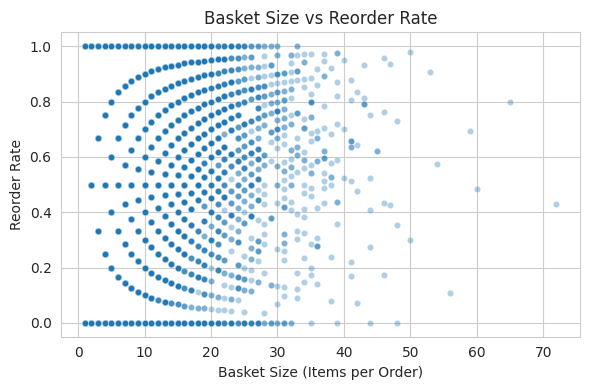

In [16]:
# Scatterplot: Basket Size vs Reorder Rate
sns.set_style("whitegrid")

plt.figure(figsize=(6,4))

sns.scatterplot(
    data=analysis_df,
    x="basket_size",
    y="reorder_rate",
    alpha=0.35,
    s=20
)

plt.title("Basket Size vs Reorder Rate")
plt.xlabel("Basket Size (Items per Order)")
plt.ylabel("Reorder Rate")

plt.tight_layout()
plt.show()

The scatterplot shows the relationship between basket size and reorder rate for Instacart orders. Most baskets contain between roughly 5 and 35 items, although some larger baskets appear as outliers. The reorder rate varies widely across all basket sizes, indicating that both small and large orders can contain a mixture of new and previously purchased items. Overall, the plot suggests that basket size alone does not strongly determine whether an order consists mostly of reordered products or exploratory purchases.

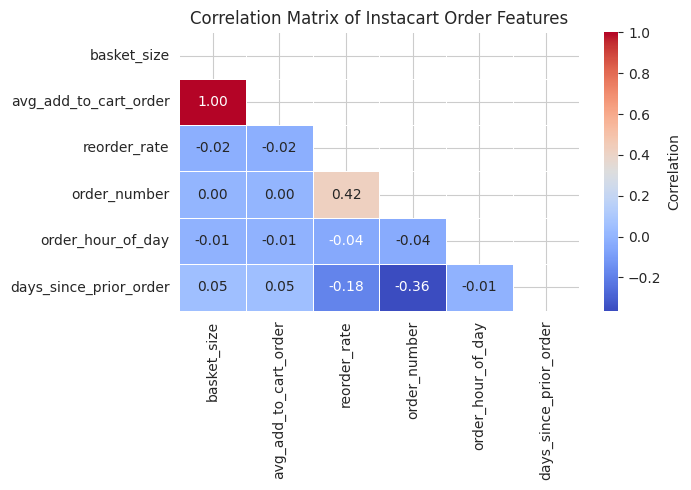

In [18]:
# Correlation Heatmap
# Compute correlation matrix
corr_vars = [
    "basket_size",
    "avg_add_to_cart_order",
    "reorder_rate",
    "order_number",
    "order_hour_of_day",
    "days_since_prior_order"
]

corr = analysis_df[corr_vars].corr()

# Mask the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(7,5))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "Correlation"}
)

plt.title("Correlation Matrix of Instacart Order Features")

plt.tight_layout()
plt.show()

The correlation matrix summarizes the relationships between several order level variables. Reorder rate shows a moderate positive correlation with order number, suggesting that customers tend to reorder more products as they place additional orders over time. Order number also shows a negative correlation with days since the prior order, indicating that experienced users tend to order more frequently. Basket size and average add to cart order show an almost perfect correlation because the average cart position is mathematically tied to the number of items in the basket, which is an expected structural relationship rather than a behavioral insight.

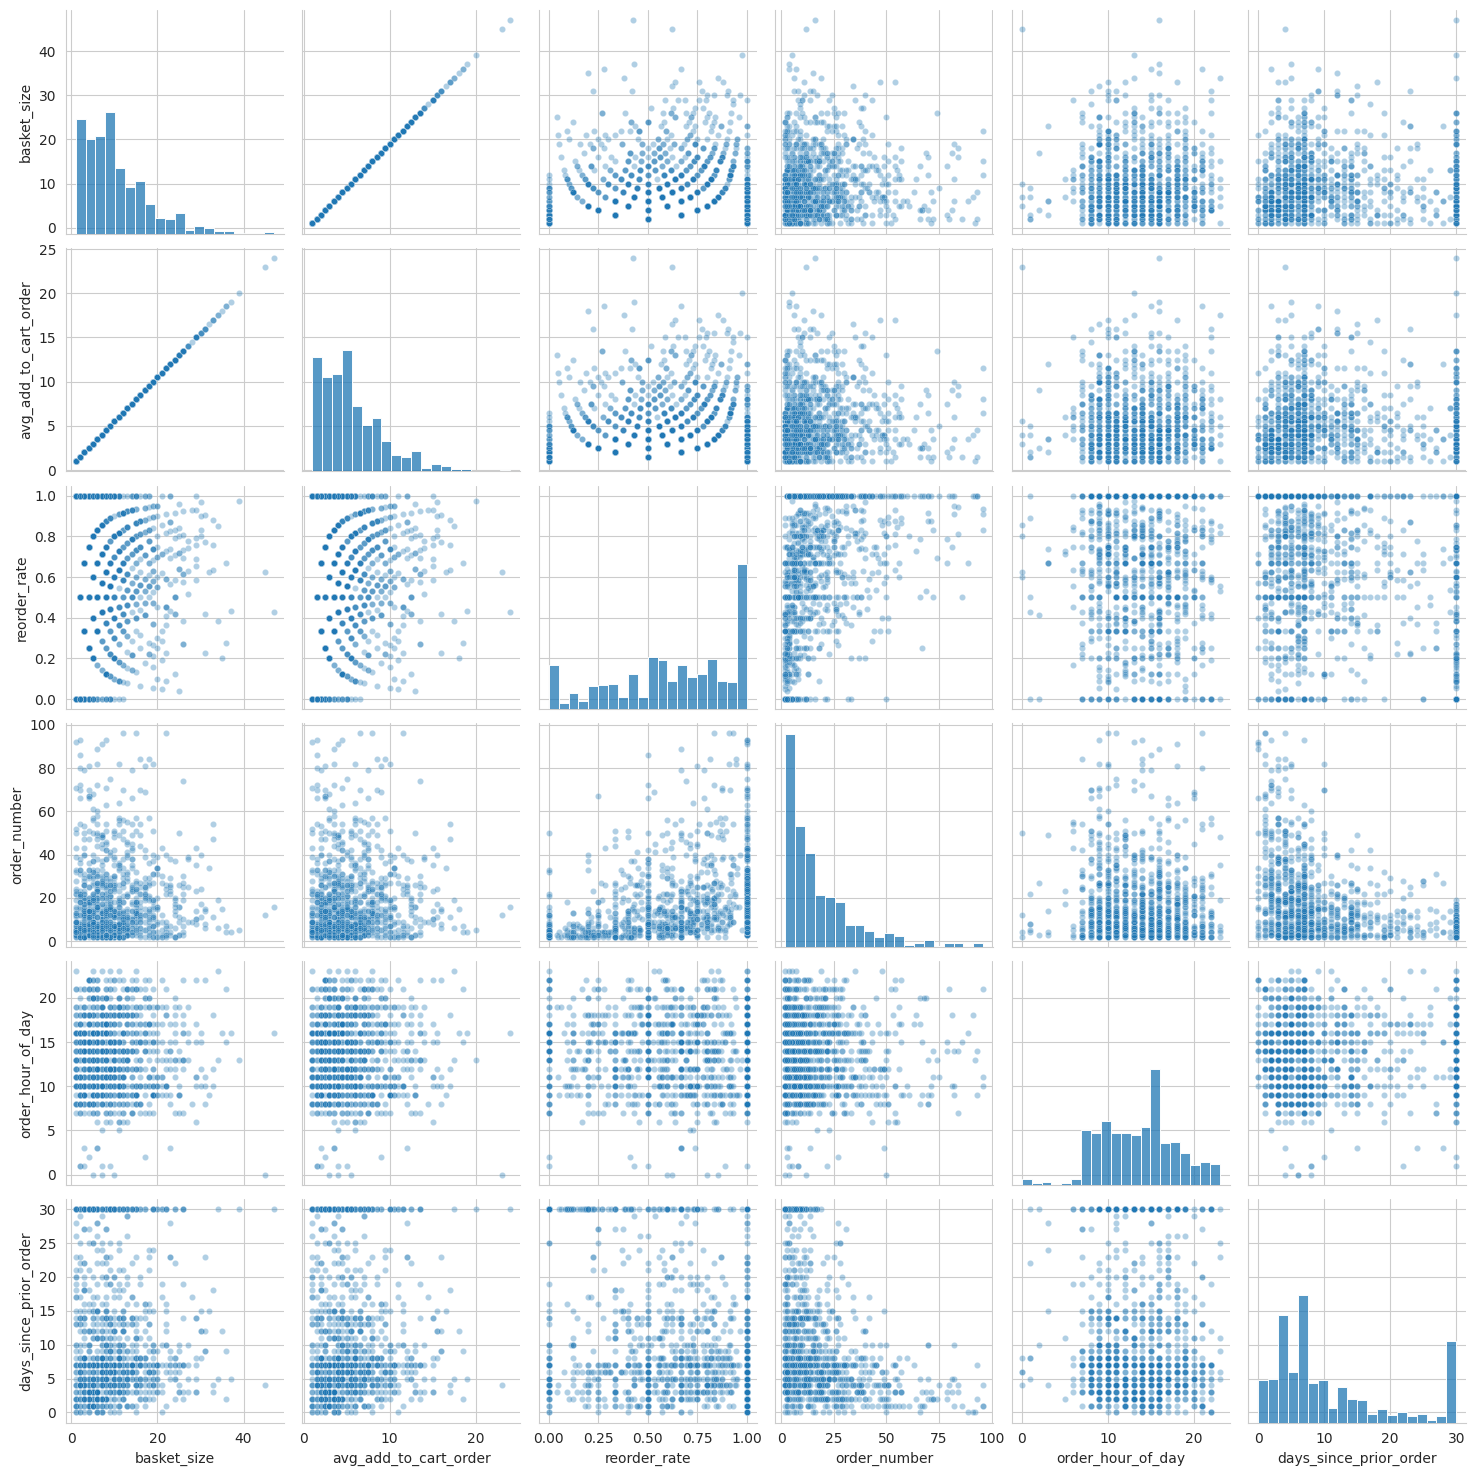

In [19]:
# Pairplot of selected variables
# Sample data to keep pairplot readable
pairplot_sample = analysis_df[corr_vars].dropna().sample(1000, random_state=42)

sns.pairplot(
    pairplot_sample,
    diag_kind="hist",
    plot_kws={"alpha":0.35, "s":20},
    diag_kws={"bins":20}
)

plt.show()

The pairplot provides a broader view of the distributions and relationships between several order features. Basket size appears right skewed, with most orders containing fewer than thirty items. Reorder rate varies substantially across users, indicating that some customers consistently reorder products while others frequently try new items. The distribution of order hour of day suggests that most orders occur during the late morning and afternoon hours. Overall, the plots show substantial variability in ordering behavior, which is typical in retail transaction data and useful for studying customer purchasing patterns.

### Conclusion

The Instacart dataset demonstrates realistic variability in shopping behavior. Basket sizes, reorder rates, and ordering patterns vary widely across users, which is expected in retail transaction data. While some variables are structurally related, such as basket size and average add to cart order, most features provide distinct behavioral signals.

The dataset appears appropriate for modeling purchasing behavior and building recommendation systems, as it contains both habitual purchasing patterns and exploratory product selections.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 86-98 of the Storytelling With Data book as best you can.  (The second half of chapter three).  You do not have to get the exact data values right, just the overall look and feel.

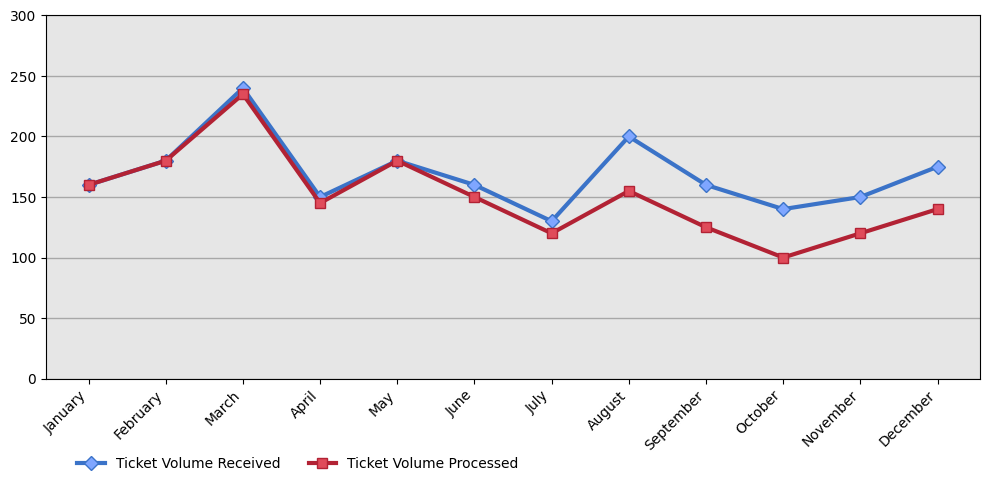

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Data approximated from the image
months = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

received = [160, 180, 240, 150, 180, 160, 130, 200, 160, 140, 150, 175]
processed = [160, 180, 235, 145, 180, 150, 120, 155, 125, 100, 120, 140]

x = np.arange(len(months))

plt.figure(figsize=(10, 5))
ax = plt.gca()

# Background color
ax.set_facecolor("#e6e6e6")

# Plot lines
plt.plot(x, received, color="#3b73c8", linewidth=3,
         marker="D", markersize=7, markerfacecolor="#7fa6ff",
         label="Ticket Volume Received")

plt.plot(x, processed, color="#b22234", linewidth=3,
         marker="s", markersize=7, markerfacecolor="#e04b5a",
         label="Ticket Volume Processed")

# Axes and ticks
plt.xticks(x, months, rotation=45, ha="right")
plt.yticks(np.arange(0, 301, 50))
plt.ylim(0, 300)

# Gridlines
plt.grid(axis="y", color="gray", linestyle="-", linewidth=1, alpha=0.6)

# Legend below plot
plt.legend(loc="upper left", bbox_to_anchor=(0.02, -0.18), ncol=2, frameon=False)

plt.tight_layout()
plt.show()